# Linux System Threat Model — RAG pipeline + traceable TARA chain

A self-contained Week 2 project that:

1. **Ingests** the Linux security PDFs in `Week 2/Data/Linux` (raw → chunk → embed
   → **ChromaDB**), with a **hash-based** incremental report.
2. Generates a complete **Linux System threat model** as a 12-entity chain, each
   entity produced by a full RAG step:

   ```
   create query → embed → retrieve (ChromaDB) → metadata filter → rerank
       → LLM (with prior entities for linking) → store → parent→child mapping
   ```
3. **Persists** every entity in a **SQLite relational DB** with the required schema
   (`entity_id, entity_type, entity_name, description, parent_entity_id,
   source_chunk_ids, retrieval_score, rerank_score, confidence_score,
   created_timestamp`) — ChromaDB source chunks linked to each artifact.

**Traceability chain**

```
Linux System / Business Use Case → Item Definition → Assets → Damage Scenarios →
Impact Rating → Threats → Attack Vectors → Attack Feasibility Rating →
Risk Value Determination → Risk Treatment Decision →
Cybersecurity Goals / Requirements → Security Test Cases
```

Everything (ChromaDB store, SQLite DB, ingestion state) is created **under this
project's `data/` folder in Week 2**.

## Prerequisites
- Source PDFs in `Week 2/Data/Linux` (Linux primer, privilege-escalation, Hacking
  Exposed Linux).
- Deps: `chromadb`, `sentence-transformers`, `torch`, `pypdf`,
  `langchain-text-splitters`, `pandas`, `matplotlib`, `openai`.
- GPU auto-detected for embeddings. `OPENAI_API_KEY` is needed to generate the
  entity outputs (without it the pipeline still ingests/retrieves/reranks and
  stores the retrieved context as a placeholder).

In [1]:
import os, re, json, hashlib, sqlite3, logging, time
from pathlib import Path
from datetime import datetime, timezone

from dotenv import load_dotenv
load_dotenv()
logging.basicConfig(level="INFO", format="%(levelname)-7s | %(message)s")
for n in ("httpx","httpcore","urllib3","huggingface_hub","filelock",
          "sentence_transformers","chromadb","chromadb.telemetry","openai","pypdf"):
    logging.getLogger(n).setLevel(logging.WARNING)

# ---- project paths (everything lives under Week 2/linux-threat-model-rag/data) ----
PROJECT_DIR = Path.cwd()
DATA_DIR    = PROJECT_DIR / "data"
CHROMA_DIR  = DATA_DIR / "chroma"
DB_PATH     = DATA_DIR / "threat_model.db"
STATE_PATH  = DATA_DIR / "ingestion_state.json"
DATA_DIR.mkdir(parents=True, exist_ok=True)

def resolve_linux_dir():
    env = os.getenv("LINUX_DATA_DIR")
    if env and Path(env).is_dir():
        return Path(env)
    for base in [PROJECT_DIR, *PROJECT_DIR.parents]:
        for cand in (base / "Data" / "Linux", base / "Week 2" / "Data" / "Linux"):
            if cand.is_dir():
                return cand
    raise FileNotFoundError("Week 2/Data/Linux not found; set LINUX_DATA_DIR.")

LINUX_DIR = resolve_linux_dir()
print("Source dir :", LINUX_DIR)
print("ChromaDB   :", CHROMA_DIR)
print("SQLite DB  :", DB_PATH)

Source dir : /workspaces/VS/MasteringAgenticAI/Week 2/Data/Linux
ChromaDB   : /workspaces/VS/MasteringAgenticAI/Week 2/linux-threat-model-rag/data/chroma
SQLite DB  : /workspaces/VS/MasteringAgenticAI/Week 2/linux-threat-model-rag/data/threat_model.db


In [2]:
import torch
from sentence_transformers import SentenceTransformer, CrossEncoder

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EMB_MODEL = "BAAI/bge-small-en-v1.5"
RERANK_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
print("device:", DEVICE)
embedder = SentenceTransformer(EMB_MODEL, device=DEVICE)
EMB_DIM = embedder.get_sentence_embedding_dimension()
reranker = CrossEncoder(RERANK_MODEL, device=DEVICE)

def embed_passages(texts):
    return embedder.encode(texts, batch_size=256, normalize_embeddings=True,
                           convert_to_numpy=True, show_progress_bar=len(texts) > 1).tolist()

def embed_query(text):
    q = "Represent this sentence for searching relevant passages: " + text
    return embedder.encode([q], normalize_embeddings=True, convert_to_numpy=True)[0].tolist()

USE_LLM = bool(os.getenv("OPENAI_API_KEY"))
MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
if USE_LLM:
    from openai import OpenAI
    oai = OpenAI()
print(f"embed dim: {EMB_DIM} | reranker: {RERANK_MODEL} | LLM: {MODEL if USE_LLM else 'OFF'}")

/home/vscode/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


device: cuda


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10982.60it/s]
/tmp/ipykernel_6195/877596666.py:9: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  EMB_DIM = embedder.get_sentence_embedding_dimension()
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 8641.60it/s]


embed dim: 384 | reranker: cross-encoder/ms-marco-MiniLM-L-6-v2 | LLM: OFF


## Part A — Ingestion: raw → chunk → embed → ChromaDB (hash-based)
Each PDF is content-hashed; unchanged files are skipped on re-run. A coarse
`category` is attached to every chunk as **metadata** (used later for filtered
retrieval).

In [3]:
import io
from pypdf import PdfReader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import chromadb

splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)

def file_hash(path, block=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for b in iter(lambda: fh.read(block), b""):
            h.update(b)
    return h.hexdigest()[:16]

def pdf_stream(path):
    data = path.read_bytes()
    if data[:5] == b"%PDF-":
        return io.BytesIO(data)
    start = data.find(b"%PDF-"); end = data.rfind(b"%%EOF")
    return io.BytesIO(data[start: end + 5] if (start != -1 and end != -1) else data)

def categorize(name):
    low = name.lower()
    if "privilege" in low:        return "privilege_escalation"
    if "hacking exposed" in low:  return "offensive_security"
    if "primer" in low:           return "primer"
    return "general"

def load_chunks(path):
    reader = PdfReader(pdf_stream(path))
    source, category = path.stem, categorize(path.name)
    out = []
    for page_no, page in enumerate(reader.pages, start=1):
        text = (page.extract_text() or "").strip()
        for j, piece in enumerate(splitter.split_text(text)):
            out.append({
                "id": f"{source}-p{page_no:04d}-c{j:02d}", "text": piece,
                "metadata": {"source": source, "source_file": path.name,
                             "page": page_no, "chunk_index": j, "category": category},
            })
    return out

chroma = chromadb.PersistentClient(path=str(CHROMA_DIR))
kb = chroma.get_or_create_collection("linux_kb", metadata={"hnsw:space": "cosine"})

state = json.loads(STATE_PATH.read_text()) if STATE_PATH.exists() else {}
ingest_report = []
for pdf in sorted(LINUX_DIR.glob("*.pdf")):
    h = file_hash(pdf)
    prev = state.get(pdf.name)
    if prev and prev.get("hash") == h and kb.get(where={"source_file": pdf.name}, limit=1)["ids"]:
        ingest_report.append({"file": pdf.name, "status": "skipped", "hash": h,
                              "chunks": prev.get("chunks", 0)})
        continue
    if prev:
        kb.delete(where={"source_file": pdf.name})
    chunks = load_chunks(pdf)
    if not chunks:
        ingest_report.append({"file": pdf.name, "status": "no_text", "hash": h, "chunks": 0})
        continue
    embs = embed_passages([c["text"] for c in chunks])
    kb.upsert(ids=[c["id"] for c in chunks], embeddings=embs,
              documents=[c["text"] for c in chunks], metadatas=[c["metadata"] for c in chunks])
    state[pdf.name] = {"hash": h, "chunks": len(chunks), "category": categorize(pdf.name)}
    ingest_report.append({"file": pdf.name, "status": "ingested", "hash": h, "chunks": len(chunks)})

STATE_PATH.write_text(json.dumps(state, indent=2))

import pandas as pd
pd.set_option("display.max_colwidth", 60)
ingest_df = pd.DataFrame(ingest_report)
print(f"ChromaDB 'linux_kb' total chunks: {kb.count()}")
ingest_df

ChromaDB 'linux_kb' total chunks: 2281


,file,status,hash,chunks
0,4 - Linux Primer.pdf,skipped,d9ebbc245837fe8a,8
1,Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE...,skipped,bb5d9b69cf76c4f0,2073
2,Linux_Privilege_Escalation_Week_I.pdf,skipped,5fd7883295cb9633,70
3,Linux_Privilege_Escalation_Week_II.pdf,skipped,ae954f17774fbb17,39
4,Linux_Privilege_Escalation_Week_III.pdf,skipped,5068b73122674188,46
5,Linux_Privilege_Escalation_Week_IV.pdf,skipped,0cd9e14178072c76,45


## Part B — Relational database schema (SQLite)
The required schema. `parent_entity_id` is the **parent→child** link up the
traceability chain; `source_chunk_ids` links each entity to the ChromaDB chunks
that grounded it.

In [4]:
conn = sqlite3.connect(DB_PATH)
conn.execute("""
CREATE TABLE IF NOT EXISTS threat_model_entities (
    entity_id         TEXT PRIMARY KEY,
    entity_type       TEXT,
    entity_name       TEXT,
    description       TEXT,
    parent_entity_id  TEXT,
    source_chunk_ids  TEXT,        -- JSON list of ChromaDB chunk ids
    retrieval_score   REAL,
    rerank_score      REAL,
    confidence_score  REAL,
    created_timestamp TEXT,
    FOREIGN KEY (parent_entity_id) REFERENCES threat_model_entities(entity_id)
)""")
conn.execute("""
CREATE TABLE IF NOT EXISTS entity_relationships (
    child_id   TEXT, parent_id TEXT, relation_type TEXT,
    PRIMARY KEY (child_id, parent_id)
)""")
# clean slate for a re-run (deterministic entity_ids would also upsert)
conn.execute("DELETE FROM threat_model_entities")
conn.execute("DELETE FROM entity_relationships")
conn.commit()

def store_entity(rec):
    conn.execute("""INSERT OR REPLACE INTO threat_model_entities VALUES
        (:entity_id,:entity_type,:entity_name,:description,:parent_entity_id,
         :source_chunk_ids,:retrieval_score,:rerank_score,:confidence_score,:created_timestamp)""", rec)
    if rec["parent_entity_id"]:
        conn.execute("INSERT OR REPLACE INTO entity_relationships VALUES (?,?,?)",
                     (rec["entity_id"], rec["parent_entity_id"], "derived_from"))
    conn.commit()

print("SQLite schema ready:", DB_PATH.name)

SQLite schema ready: threat_model.db


## Part C — The Linux System context + the TARA chain
The system under analysis and the ordered entities, each with its RAG query, a
**metadata filter** (offensive material is preferred for the threat/attack/risk
stages), and its dependency links.

In [5]:
SYSTEM = {
  "name": "Linux System",
  "context": (
    "A general-purpose Linux system comprising: the Linux kernel, boot process "
    "(bootloader/initramfs), system services (systemd), user-space applications, "
    "file system, process management, network services, authentication & "
    "authorization (PAM, users/groups, sudo), logging & audit (syslog/auditd), "
    "package management, device drivers, and security modules (SELinux/AppArmor). "
    "External interfaces: SSH, Ethernet, Wi-Fi, USB, diagnostics, and cloud "
    "connectivity."),
}

OFFENSIVE = {"category": {"$in": ["privilege_escalation", "offensive_security"]}}

# key, entity_type, label, parent_key, depends_on, where_filter, rag_query, instruction
STAGES = [
 ("use_case","UseCase","Linux System / Business Use Case", None, [], None,
  "purpose and operational context of a general purpose Linux system and its services",
  "State the business/operational use case and scope of the Linux system in 4-6 sentences."),
 ("item_definition","ItemDefinition","Item Definition","use_case",["use_case"], None,
  "how to define an item: boundary components interfaces operational environment assumptions",
  "Produce the Item Definition: boundary, components (kernel, services, fs, drivers, security modules...), interfaces (SSH/Ethernet/Wi-Fi/USB/cloud), operational environment, and assumptions."),
 ("assets","Assets","Assets","item_definition",["item_definition"], None,
  "identifying assets in a linux system and their confidentiality integrity availability properties",
  "Identify assets (ID them A1,A2,...) and each asset's cybersecurity properties (C/I/A). Reference the Item Definition components they come from."),
 ("damage_scenarios","DamageScenario","Damage Scenarios","assets",["assets"], None,
  "damage scenarios consequences of compromising confidentiality integrity availability on a linux host",
  "Derive damage scenarios (DS1,DS2,...) from violations of each asset's C/I/A. Reference the asset IDs (A#) each derives from."),
 ("impact_rating","ImpactRating","Impact Rating","damage_scenarios",["damage_scenarios"], None,
  "rating impact severity safety financial operational privacy of security incidents",
  "Rate each damage scenario (IR1 for DS1,...) across Safety/Financial/Operational/Privacy with a severity (Severe/Major/Moderate/Negligible)."),
 ("threats","Threat","Threats","impact_rating",["assets","damage_scenarios"], OFFENSIVE,
  "linux threats privilege escalation, exploitation, spoofing tampering information disclosure denial of service",
  "Identify threat scenarios (T1,T2,...) — how each asset property is compromised (STRIDE where useful). Reference the A#/DS# they target."),
 ("attack_vectors","AttackVector","Attack Vectors","threats",["threats"], OFFENSIVE,
  "linux attack paths and attack vectors privilege escalation SUID sudo kernel exploits SSH",
  "Build attack paths / vectors (AV1,AV2,...) realizing each threat. Reference the T# they realize; give the steps/entry points."),
 ("feasibility","AttackFeasibility","Attack Feasibility Rating","attack_vectors",["attack_vectors"], OFFENSIVE,
  "attack feasibility attack potential elapsed time expertise knowledge equipment, or CVSS",
  "Rate attack feasibility (AF1 for AV1,...) using attack potential (time/expertise/knowledge/window/equipment) → Low/Medium/High."),
 ("risk_value","RiskValue","Risk Value Determination","feasibility",["impact_rating","feasibility"], None,
  "determining risk value by combining impact and attack feasibility risk matrix",
  "Determine risk values (RV1,...) by combining impact (IR#) and feasibility (AF#). Reference both. Give a risk level."),
 ("risk_treatment","RiskTreatment","Risk Treatment Decision","risk_value",["risk_value"], None,
  "risk treatment options avoid reduce mitigate share transfer retain accept",
  "Decide treatment (RT1 for RV1,...): avoid/reduce/share/retain. Reference the RV# each addresses."),
 ("goals_requirements","CyberRequirement","Cybersecurity Goals / Requirements","risk_treatment",["risk_treatment","threats"], None,
  "cybersecurity goals requirements controls hardening linux SELinux AppArmor authentication patching",
  "Derive cybersecurity goals (CG1,...) and security requirements/controls (SR1,...). Reference the RT#/T# they mitigate."),
 ("test_cases","TestCase","Security Test Cases","goals_requirements",["goals_requirements"], None,
  "security test cases verifying linux hardening controls authentication logging patching",
  "Write security test cases (TC1 for SR1,...): objective + expected result. Reference the SR# each verifies."),
]
ENTITY_ID = {k: f"LIN-{i:02d}-{k}" for i, (k, *_rest) in enumerate(STAGES)}
print("Chain:", " → ".join(s[2] for s in STAGES))

Chain: Linux System / Business Use Case → Item Definition → Assets → Damage Scenarios → Impact Rating → Threats → Attack Vectors → Attack Feasibility Rating → Risk Value Determination → Risk Treatment Decision → Cybersecurity Goals / Requirements → Security Test Cases


## Part D — Per-entity RAG pipeline (the 9 steps), with linking
For each entity: **create query → embed → retrieve → metadata filter → rerank →
LLM (grounded + prior entities) → store → parent→child mapping**. Every
intermediate (retrieved ids/scores, reranked ids/scores, citations) is recorded.

In [6]:
import math

def retrieve(query, where, n=20):
    qv = embed_query(query)
    res = kb.query(query_embeddings=[qv], n_results=n, where=where,
                   include=["documents","metadatas","distances"])
    hits = [{"id": i, "text": d, "meta": m, "score": round(1 - float(dist), 4)}
            for i, d, m, dist in zip(res["ids"][0], res["documents"][0],
                                     res["metadatas"][0], res["distances"][0])]
    used_filter = bool(where)
    if where and len(hits) < 5:            # fallback so a filter never starves retrieval
        res = kb.query(query_embeddings=[qv], n_results=n,
                       include=["documents","metadatas","distances"])
        hits = [{"id": i, "text": d, "meta": m, "score": round(1 - float(dist), 4)}
                for i, d, m, dist in zip(res["ids"][0], res["documents"][0],
                                         res["metadatas"][0], res["distances"][0])]
        used_filter = False
    return hits, used_filter

def rerank(query, hits, top=6):
    if not hits:
        return []
    scores = reranker.predict([(query, h["text"]) for h in hits])
    for h, s in zip(hits, scores):
        h["rerank"] = float(s)
    return sorted(hits, key=lambda x: x["rerank"], reverse=True)[:top]

def confidence(reranked):
    if not reranked:
        return 0.0
    top = max(h["rerank"] for h in reranked)
    return round(1 / (1 + math.exp(-top)), 4)   # sigmoid of best rerank logit

def llm_generate(stage, reranked, prior_answers):
    key, etype, label, parent, depends, where, rag_q, instruction = stage
    context = "\n\n".join(
        f"[{h['meta']['source']} p.{h['meta']['page']}] " + " ".join(h["text"].split())[:500]
        for h in reranked) or "(no passages)"
    prior = "\n\n".join(f"### {STAGE_BY_KEY[d][2]}\n{prior_answers.get(d,'')[:1100]}"
                          for d in depends) or "(this is the root entity)"
    if not USE_LLM:
        return ("_(LLM disabled — grounding context only)_\n\n" + context)[:1500]
    system = ("You are a Linux security engineer performing an ISO/SAE 21434-style "
              "TARA for a Linux system. Produce ONLY this entity's output, concise and "
              "structured (tables/bullets). Build strictly on the prior entities for "
              "traceability (reuse their IDs and state what each item derives from), "
              "and ground your method in the reference passages; cite as [source p.N].")
    user = f"""System: {SYSTEM['name']}
Context: {SYSTEM['context']}

Prior entities (build on these — keep IDs consistent):
{prior}

Reference passages (method, grounded):
{context}

Task — {label}: {instruction}"""
    r = oai.chat.completions.create(model=MODEL, temperature=0.2, max_tokens=700,
        messages=[{"role":"system","content":system},{"role":"user","content":user}])
    return r.choices[0].message.content

STAGE_BY_KEY = {s[0]: s for s in STAGES}
answers, records, provenance = {}, [], []

for stage in STAGES:
    key, etype, label, parent, depends, where, rag_q, instruction = stage
    query = f"{rag_q} for a {SYSTEM['name']}"
    hits, used_filter = retrieve(query, where, n=20)
    reranked = rerank(query, hits, top=6)
    answer = llm_generate(stage, reranked, answers)
    answers[key] = answer

    src_ids   = [h["id"] for h in reranked]
    retr_top  = reranked[0]["score"]  if reranked else 0.0
    rrank_top = reranked[0]["rerank"] if reranked else 0.0
    rec = {"entity_id": ENTITY_ID[key], "entity_type": etype, "entity_name": label,
           "description": answer, "parent_entity_id": ENTITY_ID.get(parent),
           "source_chunk_ids": json.dumps(src_ids),
           "retrieval_score": round(float(retr_top), 4),
           "rerank_score": round(float(rrank_top), 4),
           "confidence_score": confidence(reranked),
           "created_timestamp": datetime.now(timezone.utc).isoformat()}
    store_entity(rec)
    records.append(rec)
    for h in reranked:
        provenance.append({"entity_id": ENTITY_ID[key], "entity_type": etype,
                           "chunk_id": h["id"], "source": h["meta"]["source"],
                           "page": h["meta"]["page"], "category": h["meta"]["category"],
                           "retrieval_score": h["score"], "rerank_score": round(h["rerank"], 3)})
    print(f"✓ {label:34} | filter={'on' if used_filter else 'off':3} | "
          f"retrieved {len(hits):2d} → reranked {len(reranked)} | "
          f"conf={rec['confidence_score']:.3f} | src={len(src_ids)} chunks")

✓ Linux System / Business Use Case   | filter=off | retrieved 20 → reranked 6 | conf=0.235 | src=6 chunks
✓ Item Definition                    | filter=off | retrieved 20 → reranked 6 | conf=0.056 | src=6 chunks
✓ Assets                             | filter=off | retrieved 20 → reranked 6 | conf=0.989 | src=6 chunks
✓ Damage Scenarios                   | filter=off | retrieved 20 → reranked 6 | conf=0.823 | src=6 chunks
✓ Impact Rating                      | filter=off | retrieved 20 → reranked 6 | conf=0.871 | src=6 chunks
✓ Threats                            | filter=on  | retrieved 20 → reranked 6 | conf=0.982 | src=6 chunks
✓ Attack Vectors                     | filter=on  | retrieved 20 → reranked 6 | conf=0.976 | src=6 chunks
✓ Attack Feasibility Rating          | filter=on  | retrieved 20 → reranked 6 | conf=0.020 | src=6 chunks
✓ Risk Value Determination           | filter=off | retrieved 20 → reranked 6 | conf=0.644 | src=6 chunks
✓ Risk Treatment Decision            | filter=

## Part E — Final outputs

### 1. Linux threat model summary

In [7]:
def section(label, body): return f"## {label}\n\n{body}\n"
report_md = f"# Linux System — Threat Model (TARA)\n\n_{SYSTEM['name']}: {SYSTEM['context']}_\n\n" + \
            "\n".join(section(s[2], answers[s[0]]) for s in STAGES)
report_path = DATA_DIR / "linux_threat_model.md"
report_path.write_text(report_md, encoding="utf-8")
print(f"Saved {report_path}  ({len(report_md):,} chars)\n")
from IPython.display import Markdown, display
display(Markdown(report_md[:2500] + "\n\n… _(full report saved to data/linux_threat_model.md)_"))

Saved /workspaces/VS/MasteringAgenticAI/Week 2/linux-threat-model-rag/data/linux_threat_model.md  (18,820 chars)



# Linux System — Threat Model (TARA)

_Linux System: A general-purpose Linux system comprising: the Linux kernel, boot process (bootloader/initramfs), system services (systemd), user-space applications, file system, process management, network services, authentication & authorization (PAM, users/groups, sudo), logging & audit (syslog/auditd), package management, device drivers, and security modules (SELinux/AppArmor). External interfaces: SSH, Ethernet, Wi-Fi, USB, diagnostics, and cloud connectivity._

## Linux System / Business Use Case

_(LLM disabled — grounding context only)_

[Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE_GEORGE KURT p.47] 12 Hacking Exposed Linux: Linux Security Secrets & Solutions A proper application of security means the attack surface is limited to the known and desired available services. For any and all uses of a Linux system, there should be no mystery as to where an attack could happen. By assuring the only holes in security are the intentional ones, which were inserted for the sake of productivity, then only those intentional holes should be available for attack and no others.

[Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE_GEORGE KURT p.72] watched by another network sensor as per its uptime, load, and activity. SUMMARY The use of process controls such as non-repudiation, confidentiality, privacy, integrity, and alarms will greatly enhance the security of assets on a Linux system. Understanding these controls and how to recognize them will allow you to approach the other chapters in this book with greater understanding toward building a more thoroughly controlled system.

[4 - Linux Primer p.2] Linux the Hackers Most Useful Tool•Linux provides some incredible utility right out of the box. •Basicallyeverything you need to conduct security research•File operations, binary analysis, efficient searching and scanning•The most useful skill you can take from this course might be the familiarity you have the opportunity togain with the Linux command line © 2021 Ba

## Item Definition

_(LLM disabled — grounding context only)_

[Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE_GEORGE KURT p.552] • The source code of Linux or at least of the ToA. • Sufﬁ cient time and effort. • A precise deﬁ nition of the ToA. Given these elements, you begin to build the specification of the modules that are used by the ToA and considered correct. Their specification consists of a set of modules containing models of var

… _(full report saved to data/linux_threat_model.md)_

### 2. Full relationship graph — Linux System → Security Test Cases

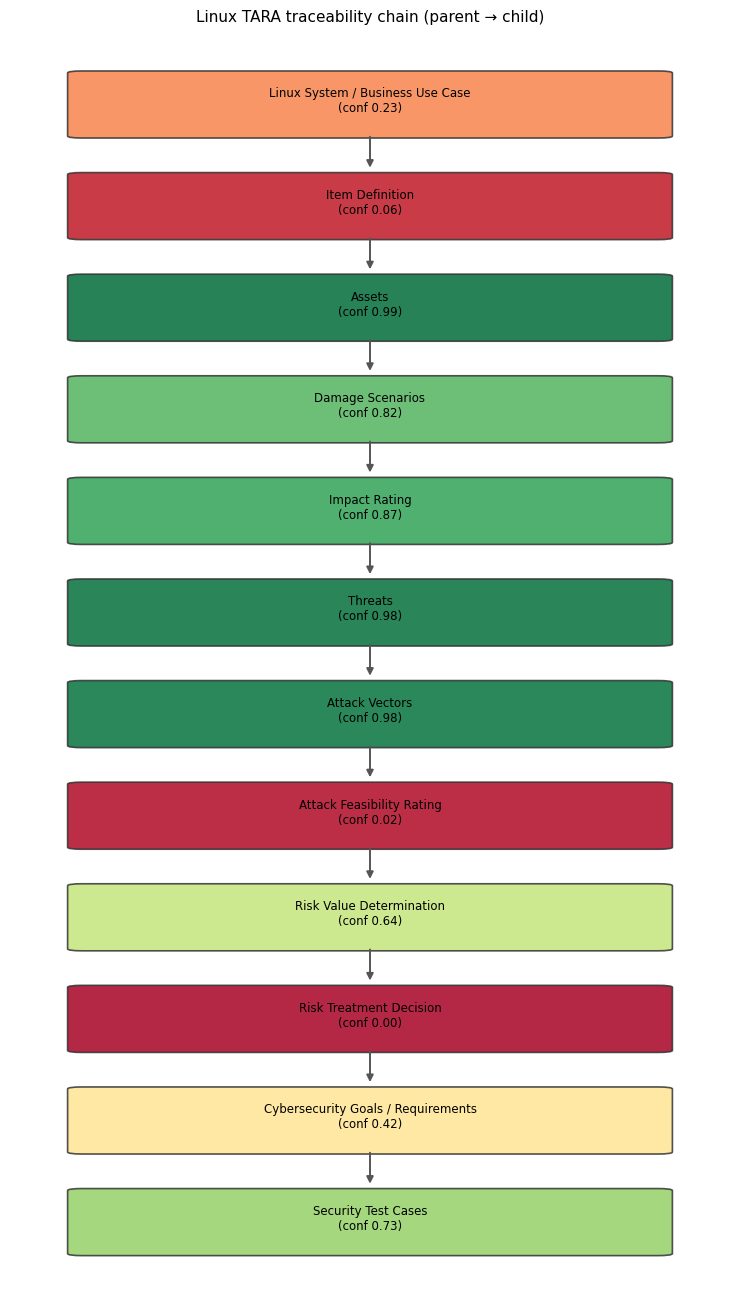

Parent → child edges (from entity_relationships):
  LIN-00-use_case  --derived_from-->  LIN-01-item_definition
  LIN-01-item_definition  --derived_from-->  LIN-02-assets
  LIN-02-assets  --derived_from-->  LIN-03-damage_scenarios
  LIN-03-damage_scenarios  --derived_from-->  LIN-04-impact_rating
  LIN-04-impact_rating  --derived_from-->  LIN-05-threats
  LIN-05-threats  --derived_from-->  LIN-06-attack_vectors
  LIN-06-attack_vectors  --derived_from-->  LIN-07-feasibility
  LIN-07-feasibility  --derived_from-->  LIN-08-risk_value
  LIN-08-risk_value  --derived_from-->  LIN-09-risk_treatment
  LIN-09-risk_treatment  --derived_from-->  LIN-10-goals_requirements
  LIN-10-goals_requirements  --derived_from-->  LIN-11-test_cases


In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

rows = conn.execute("""SELECT entity_id, entity_type, entity_name, parent_entity_id,
                       confidence_score FROM threat_model_entities""").fetchall()
by_id = {r[0]: r for r in rows}
# order by the chain (follow parent links from the root)
order = [s[0] for s in STAGES]
fig, ax = plt.subplots(figsize=(7.5, 13))
y = len(order)
pos = {}
for k in order:
    eid = ENTITY_ID[k]; _, etype, name, parent, conf = by_id[eid]
    pos[eid] = y
    color = plt.cm.RdYlGn(min(1.0, conf))
    ax.add_patch(FancyBboxPatch((0.1, y-0.34), 0.8, 0.62, boxstyle="round,pad=0.02",
                 linewidth=1.2, edgecolor="#333", facecolor=color, alpha=0.85))
    ax.text(0.5, y, f"{name}\n(conf {conf:.2f})", ha="center", va="center", fontsize=8.5)
    y -= 1
for eid, (_, _, _, parent, _) in by_id.items():
    if parent and parent in pos:
        ax.annotate("", xy=(0.5, pos[eid]+0.32), xytext=(0.5, pos[parent]-0.32),
                    arrowprops=dict(arrowstyle="-|>", color="#555", lw=1.4))
ax.set_xlim(0, 1); ax.set_ylim(0.4, len(order)+0.7); ax.axis("off")
ax.set_title("Linux TARA traceability chain (parent → child)", fontsize=11)
plt.tight_layout(); plt.show()

print("Parent → child edges (from entity_relationships):")
for c, p, t in conn.execute("SELECT child_id,parent_id,relation_type FROM entity_relationships ORDER BY child_id"):
    print(f"  {p}  --{t}-->  {c}")

### 3. Table of retrieved source chunks used for each entity

In [9]:
prov_df = pd.DataFrame(provenance)
print(f"{len(prov_df)} (entity, chunk) provenance links across {prov_df['entity_id'].nunique()} entities")
prov_df.head(25)

72 (entity, chunk) provenance links across 12 entities


,entity_id,entity_type,chunk_id,source,page,category,retrieval_score,rerank_score
0,LIN-00-use_case,UseCase,Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE...,Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE...,47,offensive_security,0.7267,-1.180
1,LIN-00-use_case,UseCase,Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE...,Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE...,72,offensive_security,0.7458,-2.372
2,LIN-00-use_case,UseCase,4 - Linux Primer-p0002-c00,4 - Linux Primer,2,primer,0.6891,-2.970
3,LIN-00-use_case,UseCase,Linux_Privilege_Escalation_Week_I-p0011-c00,Linux_Privilege_Escalation_Week_I,11,privilege_escalation,0.7420,-3.178
4,LIN-00-use_case,UseCase,Linux_Privilege_Escalation_Week_I-p0013-c00,Linux_Privilege_Escalation_Week_I,13,privilege_escalation,0.7010,-3.237
5,LIN-00-use_case,UseCase,Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE...,Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE...,559,offensive_security,0.7010,-3.585
6,LIN-01-item_definition,ItemDefinition,Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE...,Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE...,552,offensive_security,0.6928,-2.818
7,LIN-01-item_definition,ItemDefinition,Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE...,Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE...,374,offensive_security,0.6715,-5.838
8,LIN-01-item_definition,ItemDefinition,Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE...,Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE...,43,offensive_security,0.6916,-6.708
9,LIN-01-item_definition,ItemDefinition,Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE...,Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE...,567,offensive_security,0.6791,-6.857


### 4. Stored database records (SQLite)

In [10]:
db_df = pd.read_sql_query("""
    SELECT entity_id, entity_type, entity_name, parent_entity_id,
           retrieval_score, rerank_score, confidence_score,
           json_array_length(source_chunk_ids) AS n_sources, created_timestamp
    FROM threat_model_entities ORDER BY entity_id""", conn)
db_df

,entity_id,entity_type,entity_name,parent_entity_id,retrieval_score,rerank_score,confidence_score,n_sources,created_timestamp
0,LIN-00-use_case,UseCase,Linux System / Business Use Case,NaN,0.7267,-1.1801,0.2350,6,2026-06-10T04:07:18.325633+00:00
1,LIN-01-item_definition,ItemDefinition,Item Definition,LIN-00-use_case,0.6928,-2.8181,0.0564,6,2026-06-10T04:07:18.367001+00:00
2,LIN-02-assets,Assets,Assets,LIN-01-item_definition,0.7977,4.4664,0.9886,6,2026-06-10T04:07:18.403192+00:00
3,LIN-03-damage_scenarios,DamageScenario,Damage Scenarios,LIN-02-assets,0.7436,1.5387,0.8233,6,2026-06-10T04:07:18.440029+00:00
4,LIN-04-impact_rating,ImpactRating,Impact Rating,LIN-03-damage_scenarios,0.7259,1.9091,0.8709,6,2026-06-10T04:07:18.464379+00:00
5,LIN-05-threats,Threat,Threats,LIN-04-impact_rating,0.7426,3.9981,0.9820,6,2026-06-10T04:07:18.512411+00:00
6,LIN-06-attack_vectors,AttackVector,Attack Vectors,LIN-05-threats,0.7502,3.7100,0.9761,6,2026-06-10T04:07:18.552613+00:00
7,LIN-07-feasibility,AttackFeasibility,Attack Feasibility Rating,LIN-06-attack_vectors,0.6991,-3.8943,0.0200,6,2026-06-10T04:07:18.589138+00:00
8,LIN-08-risk_value,RiskValue,Risk Value Determination,LIN-07-feasibility,0.7660,0.5929,0.6440,6,2026-06-10T04:07:18.627990+00:00
9,LIN-09-risk_treatment,RiskTreatment,Risk Treatment Decision,LIN-08-risk_value,0.7208,-5.3559,0.0047,6,2026-06-10T04:07:18.663108+00:00


### 5. ChromaDB collection statistics

In [11]:
cats = {}
got = kb.get(include=["metadatas"])
for m in got["metadatas"]:
    cats[m["category"]] = cats.get(m["category"], 0) + 1
print(f"Collection: 'linux_kb' @ {CHROMA_DIR}")
print(f"  total chunks : {kb.count()}")
print(f"  embedding dim: {EMB_DIM} (cosine)")
print(f"  by category  : {cats}")
print(f"  source files : {sorted(set(m['source_file'] for m in got['metadatas']))}")

Collection: 'linux_kb' @ /workspaces/VS/MasteringAgenticAI/Week 2/linux-threat-model-rag/data/chroma
  total chunks : 2281
  embedding dim: 384 (cosine)
  by category  : {'primer': 8, 'offensive_security': 2073, 'privilege_escalation': 200}
  source files : ['4 - Linux Primer.pdf', 'Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE_GEORGE KURT.pdf', 'Linux_Privilege_Escalation_Week_I.pdf', 'Linux_Privilege_Escalation_Week_II.pdf', 'Linux_Privilege_Escalation_Week_III.pdf', 'Linux_Privilege_Escalation_Week_IV.pdf']


### 6. Hash-based ingestion report

In [12]:
print("Per-file content hash + status (incremental on re-run):")
display(ingest_df)
print("ingestion_state.json:", json.dumps(json.loads(STATE_PATH.read_text()), indent=2)[:600], "…")

Per-file content hash + status (incremental on re-run):


,file,status,hash,chunks
0,4 - Linux Primer.pdf,skipped,d9ebbc245837fe8a,8
1,Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE...,skipped,bb5d9b69cf76c4f0,2073
2,Linux_Privilege_Escalation_Week_I.pdf,skipped,5fd7883295cb9633,70
3,Linux_Privilege_Escalation_Week_II.pdf,skipped,ae954f17774fbb17,39
4,Linux_Privilege_Escalation_Week_III.pdf,skipped,5068b73122674188,46
5,Linux_Privilege_Escalation_Week_IV.pdf,skipped,0cd9e14178072c76,45


ingestion_state.json: {
  "4 - Linux Primer.pdf": {
    "hash": "d9ebbc245837fe8a",
    "chunks": 8,
    "category": "primer"
  },
  "Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE_GEORGE KURT.pdf": {
    "hash": "bb5d9b69cf76c4f0",
    "chunks": 2073,
    "category": "offensive_security"
  },
  "Linux_Privilege_Escalation_Week_I.pdf": {
    "hash": "5fd7883295cb9633",
    "chunks": 70,
    "category": "privilege_escalation"
  },
  "Linux_Privilege_Escalation_Week_II.pdf": {
    "hash": "ae954f17774fbb17",
    "chunks": 39,
    "category": "privilege_escalation"
  },
  "Linux_Privilege_Escalation_Week_III …


### 7. End-to-end traceability report

In [13]:
print("LINUX SYSTEM TARA — END-TO-END TRACEABILITY\n" + "="*70)
for s in STAGES:
    eid = ENTITY_ID[s[0]]
    r = conn.execute("""SELECT entity_type, entity_name, parent_entity_id,
                        source_chunk_ids, confidence_score FROM threat_model_entities
                        WHERE entity_id=?""", (eid,)).fetchone()
    etype, name, parent, src_json, conf = r
    src = json.loads(src_json)
    srcs = sorted(set(provenance_src.get(c, "?") for c in src)) if (provenance_src:=
           {p['chunk_id']: f"{p['source']} p.{p['page']}" for p in provenance}) else []
    print(f"\n[{eid}] {name}  (type={etype}, confidence={conf:.2f})")
    print(f"   parent: {parent or '— (root)'}")
    print(f"   grounded in {len(src)} ChromaDB chunks, e.g.: {', '.join(srcs[:4])}")
print("\n" + "="*70)
print("Traceability verified: every entity links to a parent (except the root) "
      "and to its ChromaDB source chunks.")

LINUX SYSTEM TARA — END-TO-END TRACEABILITY

[LIN-00-use_case] Linux System / Business Use Case  (type=UseCase, confidence=0.23)
   parent: — (root)
   grounded in 6 ChromaDB chunks, e.g.: 4 - Linux Primer p.2, Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE_GEORGE KURT p.47, Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE_GEORGE KURT p.559, Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE_GEORGE KURT p.72

[LIN-01-item_definition] Item Definition  (type=ItemDefinition, confidence=0.06)
   parent: LIN-00-use_case
   grounded in 6 ChromaDB chunks, e.g.: Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE_GEORGE KURT p.107, Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE_GEORGE KURT p.374, Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE_GEORGE KURT p.387, Hacking Exposed Linux 3rd - JOEL SCAMBRAY_STUART MCCLURE_GEORGE KURT p.43

[LIN-02-assets] Assets  (type=Assets, confidence=0.99)
   parent: LIN-01-item_definition
   grounded in 6 Chroma

## Notes & cleanup
- **Linking model:** `parent_entity_id` gives the linear chain (System → … → Test
  Cases); the LLM also reuses prior IDs (A#, DS#, T#, AV#, RV#, SR#, TC#) inside the
  text so traceability is visible in the content too. `source_chunk_ids` ties each
  entity back to the exact ChromaDB chunks that grounded it.
- **Metadata filtering:** threat / attack / feasibility entities prefer the
  offensive-security + privilege-escalation material via a Chroma `where` filter,
  with a fallback to unfiltered retrieval if a filter is too narrow.
- **Confidence** is a heuristic: `sigmoid(best cross-encoder rerank score)`.
- **Re-runs** are idempotent: file hashes skip unchanged PDFs; entity rows use
  `INSERT OR REPLACE` on deterministic `entity_id`s.
- This is a training artifact — outputs assist analysis, not a certified TARA.

In [14]:
conn.commit()
print("Artifacts under", DATA_DIR, ":")
for p in sorted(DATA_DIR.rglob("*")):
    if p.is_file():
        print("  ", p.relative_to(DATA_DIR), f"({p.stat().st_size:,} B)")
print("\nSummary:",
      {"kb_chunks": kb.count(), "entities": len(records),
       "provenance_links": len(provenance),
       "files_ingested": sum(1 for r in ingest_report if r['status']=='ingested')})
print("OK — ingest → per-entity RAG → SQLite store → traceability complete.")
conn.close()

Artifacts under /workspaces/VS/MasteringAgenticAI/Week 2/linux-threat-model-rag/data :
   chroma/chroma.sqlite3 (21,344,256 B)
   chroma/e7f9e8d3-d753-4428-ad6a-795b50fccfc1/data_level0.bin (3,487,756 B)
   chroma/e7f9e8d3-d753-4428-ad6a-795b50fccfc1/header.bin (100 B)
   chroma/e7f9e8d3-d753-4428-ad6a-795b50fccfc1/index_metadata.pickle (365,560 B)
   chroma/e7f9e8d3-d753-4428-ad6a-795b50fccfc1/length.bin (8,324 B)
   chroma/e7f9e8d3-d753-4428-ad6a-795b50fccfc1/link_lists.bin (18,524 B)
   ingestion_state.json (843 B)
   linux_threat_model.md (18,919 B)
   threat_model.db (65,536 B)

Summary: {'kb_chunks': 2281, 'entities': 12, 'provenance_links': 72, 'files_ingested': 0}
OK — ingest → per-entity RAG → SQLite store → traceability complete.
